#### loading week 7 model

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix
import pickle

# Load model
with open('best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

# Load test splits
X_test = pd.read_csv('X_test_cleaned.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Load your cleaned dataframe (the one before one-hot encoding)
df_clean = pd.read_csv('nhanes_clean.csv')  # adjust filename to yours

print(X_test.shape, y_test.shape, df_clean.shape)
print(df_clean.columns.tolist())
print(df_clean.head(2))

(803, 22) (803,) (4015, 16)
['age', 'gender', 'ethnicity', 'education', 'marital_status', 'poverty_ratio', 'bmi', 'height_cm', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'map_pressure', 'pulse_pressure', 'bmi_category', 'hypertension', 'age_group']
   age  gender           ethnicity          education marital_status  \
0   75  Female  Non-Hispanic Black       Some college        Widowed   
1   56    Male  Non-Hispanic Asian  College graduate+        Married   

   poverty_ratio   bmi  height_cm  weight_kg  systolic_bp  diastolic_bp  \
0           0.41  38.9      151.1       88.8          120            66   
1           5.00  21.3      170.6       62.1          108            68   

   map_pressure  pulse_pressure bmi_category  hypertension age_group  
0     84.000000              54        Obese             0     60-74  
1     81.333333              40       Normal             0     45-59  


#### Defining Subgroups to audit

In [24]:
# Pull demographic columns for test set rows using the index
demo_cols = ['age_group', 'gender', 'ethnicity', 'education', 'poverty_ratio', 'age']

df_test_demo = df_clean.loc[X_test.index, demo_cols].copy()

# Add poverty quartile as a new column (we'll slice by this instead of raw poverty_ratio)
df_test_demo['poverty_quartile'] = pd.qcut(
    df_test_demo['poverty_ratio'], 
    q=4, 
    labels=['Q1 (poorest)', 'Q2', 'Q3', 'Q4 (richest)']
)

# Quick sanity check
print(df_test_demo.shape)
print(df_test_demo.isnull().sum())
print(df_test_demo['ethnicity'].value_counts())

(803, 7)
age_group           0
gender              0
ethnicity           0
education           0
poverty_ratio       0
age                 0
poverty_quartile    0
dtype: int64
ethnicity
Non-Hispanic White    296
Non-Hispanic Black    171
Non-Hispanic Asian    116
Mexican American      107
Other Hispanic         67
Other/Multi-Racial     46
Name: count, dtype: int64


#### Compute AUC-ROC, sensitivity & specificity per group

In [25]:
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix

def compute_subgroup_metrics(group_name, mask):
    """
    Given a boolean mask selecting a subgroup from X_test,
    compute key classification metrics for that group.
    """
    X_sub = X_test[mask]
    y_sub = y_test[mask]
    
    if len(y_sub) < 30:
        return None  # too small to trust
    
    y_prob = best_model.predict_proba(X_sub)[:, 1]
    y_pred = (y_prob >= 0.3).astype(int)  # same threshold from Week 7
    
    tn, fp, fn, tp = confusion_matrix(y_sub, y_pred).ravel()
    
    return {
        'group': group_name,
        'n': len(y_sub),
        'prevalence': round(y_sub.mean(), 3),
        'auc': round(roc_auc_score(y_sub, y_prob), 3),
        'sensitivity': round(tp / (tp + fn), 3),  # recall — catching actual hypertensives
        'specificity': round(tn / (tn + fp), 3),  # avoiding false alarms
        'n_flagged_small': len(y_sub) < 50
    }

# Quick test on the full test set first
mask_all = pd.Series([True] * len(X_test), index=X_test.index)
print(compute_subgroup_metrics('Overall', mask_all))


{'group': 'Overall', 'n': 803, 'prevalence': np.float64(0.245), 'auc': 0.728, 'sensitivity': np.float64(0.873), 'specificity': np.float64(0.474), 'n_flagged_small': False}


In [26]:
# Run across all subgroups
results = []

# Overall baseline
results.append(compute_subgroup_metrics('Overall', pd.Series([True] * len(X_test), index=X_test.index)))

# Gender
for val in df_test_demo['gender'].unique():
    mask = df_test_demo['gender'] == val
    results.append(compute_subgroup_metrics(f'Gender: {val}', mask))

# Ethnicity
for val in df_test_demo['ethnicity'].unique():
    mask = df_test_demo['ethnicity'] == val
    results.append(compute_subgroup_metrics(f'Ethnicity: {val}', mask))

# Age group
for val in df_test_demo['age_group'].unique():
    mask = df_test_demo['age_group'] == val
    results.append(compute_subgroup_metrics(f'Age: {val}', mask))

# Education
for val in df_test_demo['education'].unique():
    mask = df_test_demo['education'] == val
    results.append(compute_subgroup_metrics(f'Education: {val}', mask))

# Poverty quartile
for val in df_test_demo['poverty_quartile'].unique():
    mask = df_test_demo['poverty_quartile'] == val
    results.append(compute_subgroup_metrics(f'Poverty: {val}', mask))

# Build results table — drop None (groups too small)
results = [r for r in results if r is not None]
df_results = pd.DataFrame(results).sort_values('auc')

print(df_results.to_string(index=False))

                         group   n  prevalence   auc  sensitivity  specificity  n_flagged_small
                      Age: 75+  74       0.203 0.619        0.733        0.424            False
       Education: 9-11th grade 102       0.196 0.665        0.800        0.463            False
 Ethnicity: Non-Hispanic Black 171       0.199 0.680        0.735        0.453            False
                    Age: 45-59 201       0.274 0.691        0.891        0.459            False
                   Poverty: Q3 201       0.234 0.708        0.872        0.435            False
                Gender: Female 418       0.225 0.709        0.872        0.451            False
                    Age: 30-44 200       0.240 0.709        0.875        0.467            False
         Poverty: Q4 (richest) 198       0.253 0.712        0.900        0.480            False
  Education: College graduate+ 207       0.232 0.712        0.958        0.453            False
 Ethnicity: Other/Multi-Racial  46      

#### Grouped bar charts for every demographic axis

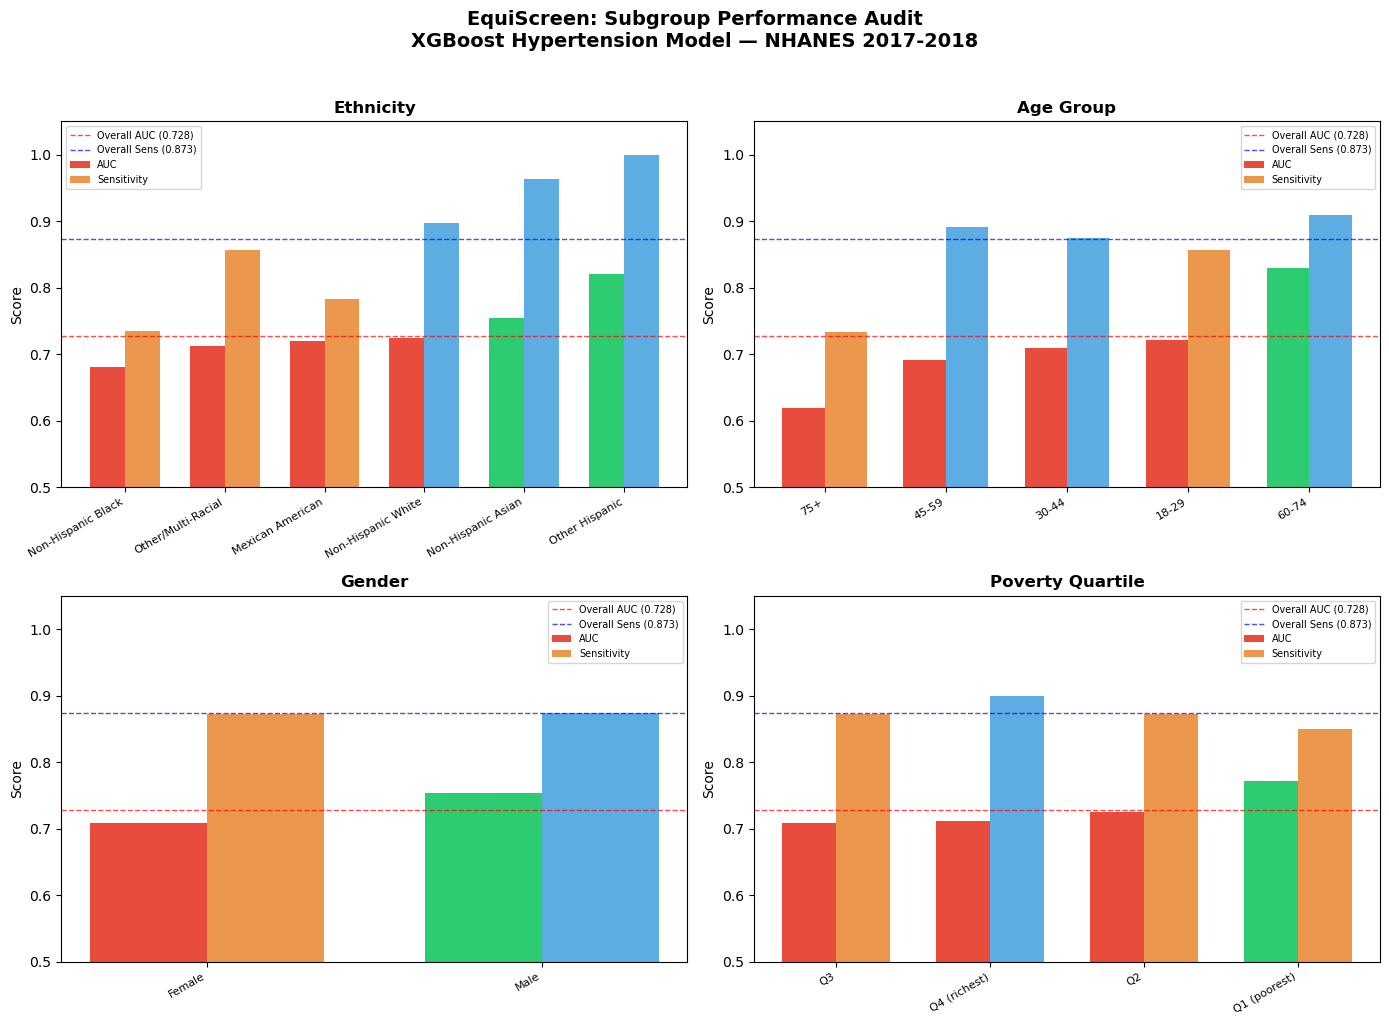

Chart saved!


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EquiScreen: Subgroup Performance Audit\nXGBoost Hypertension Model — NHANES 2017-2018', 
             fontsize=14, fontweight='bold', y=1.02)

overall_auc = 0.728
overall_sens = 0.873

dimensions = [
    ('ethnicity', 'Ethnicity', axes[0, 0]),
    ('age_group', 'Age Group', axes[0, 1]),
    ('gender', 'Gender', axes[1, 0]),
    ('poverty_quartile', 'Poverty Quartile', axes[1, 1]),
]

for col, title, ax in dimensions:
    subset = df_results[df_results['group'].str.startswith(title.split()[0])]
    
    x = range(len(subset))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], subset['auc'], width, 
                   label='AUC', color=['#e74c3c' if v < overall_auc else '#2ecc71' for v in subset['auc']])
    bars2 = ax.bar([i + width/2 for i in x], subset['sensitivity'], width,
                   label='Sensitivity', color=['#e67e22' if v < overall_sens else '#3498db' for v in subset['sensitivity']], alpha=0.8)
    
    ax.axhline(y=overall_auc, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Overall AUC ({overall_auc})')
    ax.axhline(y=overall_sens, color='blue', linestyle='--', linewidth=1, alpha=0.7, label=f'Overall Sens ({overall_sens})')
    
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([g.split(': ')[1] for g in subset['group']], rotation=30, ha='right', fontsize=8)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('week8_subgroup_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

##### The subgroup audit reveals meaningful performance disparities across ethnicity groups. Non-Hispanic Black patients show the lowest AUC (0.680) and sensitivity (0.735) in the ethnicity dimension, both substantially below the overall benchmarks of 0.728 and 0.873 respectively. This means the model misses a disproportionate number of actual hypertensive cases in this group — a clinically significant finding, as undetected hypertension increases risk of stroke, heart attack, and kidney failure. By contrast, Non-Hispanic White patients perform closest to the overall benchmark (AUC 0.725, sensitivity 0.897), suggesting the model is effectively calibrated for this group. Other Hispanic patients show unusually high sensitivity (1.000), but this should be interpreted cautiously — the group contains only 67 people, and specificity is just 0.543, meaning the model incorrectly flags nearly half of healthy patients in this group as hypertensive. High sensitivity at the cost of specificity is not a sign of a well-performing model; it suggests the model may be defaulting to over-prediction for this subgroup rather than genuinely discriminating between cases.

##### The age group audit reveals the sharpest performance disparity in the entire analysis. Patients aged 75 and above show the lowest AUC (0.619) and sensitivity (0.733) of any subgroup examined, falling substantially below the overall benchmarks of 0.728 and 0.873 respectively. This represents a 0.109 AUC gap — the largest single disparity found in the audit. Clinically, this is concerning: elderly patients are among the highest-risk group for hypertension complications, yet the model performs worst precisely for them. This likely reflects the complexity of hypertension in older patients, who may be on medication that suppresses blood pressure readings, making the model's features less informative. By contrast, the 60-74 age group shows the strongest performance (AUC 0.830, sensitivity 0.909), though specificity remains low at 0.510, indicating the model still struggles to correctly clear healthy patients in this group. The 30-44 group performs closest to the overall benchmark, suggesting the model is most reliably calibrated for middle-aged adults — likely because this demographic is most represented in the training data.


##### The subgroup audit identifies three groups most underserved by the model. First, patients aged 75 and above show the largest single performance gap in the entire analysis — AUC 0.619 versus the overall 0.728, a difference of 0.109. This is likely because elderly hypertension is clinically complex: many older patients are already on antihypertensive medication, which actively suppresses their blood pressure readings. The model's features therefore look "normal" for someone who is actually hypertensive but medicated, making correct classification harder. Second, Non-Hispanic Black patients show an AUC of 0.680, the lowest among ethnic groups. This is the most socially significant finding — Black Americans carry a disproportionately high hypertension burden in real life, yet the model serves them worst. This may reflect underrepresentation in the training data, or systemic differences in how hypertension presents and is documented in this population. Third, patients with 9-11th grade education show AUC 0.665. Lower educational attainment correlates with lower health literacy, less frequent healthcare engagement, and more unmanaged hypertension — patterns the model's current features may not capture well. Taken together, the model performs worst for groups who are already at higher clinical risk — precisely the patients where accurate prediction matters most.